# L5a Advanced: Sampling Error and Shrinkage in Covariance Estimation

In the L5a covariance example, we estimated how the growth rates of different firms vary together. These estimates depend on the observations available to us. With $M$ firms, the covariance matrix contains $M(M+1)/2$ distinct entries, so estimating a large matrix from a limited history can introduce substantial sampling error.

Why does this matter for portfolio construction? A minimum-variance calculation can assign large weights to combinations of assets whose estimated variance is small. If that estimate is too low because of sampling error, the resulting portfolio may have more risk than the estimate suggests.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Interpret a sample correlation spectrum:** Compare its eigenvalues with the Marchenko-Pastur noise model and explain what this comparison can tell us about shared variation among firms.
> * **Measure covariance estimation error:** Simulate growth rates from a known covariance matrix and examine how sample size affects the overall estimation error and the smallest estimated eigenvalue.
> * **Evaluate covariance shrinkage:** Compare three shrinkage targets and examine how the target and its weight affect minimum-variance weights and the variability of the linear growth-rate proxy on a later data window.

In this example, we will examine the sample correlation matrix for our course dataset, use simulation to measure sampling error, and compare raw and shrunk covariance estimates in a portfolio calculation. We will use the lecture's linear growth-rate proxy to compare risk, and distinguish an illustrative comparison on one later window from a validated choice of estimator.

Let's get started!

___


## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project and loads the packages and local helper functions used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # Load the local setup file.

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

The local functions and their Julia docstrings are in [src/CovarianceEstimation.jl](src/CovarianceEstimation.jl), loaded by [Include.jl](Include.jl).

Let's set the plotting defaults for our figures:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

### Data
We use the course dataset of daily price records from January 3, 2014, through December 31, 2024. Each firm's price observation is the daily volume-weighted average price, stored in the `volume_weighted_average_price` column. This is the same dataset used in the L5a covariance example.

Not all firms have the same number of observations. We use `AAPL` as the reference, retain firms with the same number of daily records, and sort their ticker symbols alphabetically. The retained histories in this dataset have matching trading dates, so we can compare the firms over the same daily intervals.

Recall how we convert prices into growth rates. If $S_i(t_k)$ is the observed price of firm $i$ on trading day $k$, its growth rate over the preceding interval is given by:
$$
g_k^{(i)}=\frac{1}{\Delta t}\ln\!\left(\frac{S_i(t_k)}{S_i(t_{k-1})}\right),
\qquad \Delta t=\frac{1}{252}\ \text{years}.
$$
The growth rates have units of inverse years. We arrange them in the matrix $\mathbf{G}\in\mathbb{R}^{N\times M}$, with one row for each of the $N$ daily intervals and one column for each of the $M$ retained firms. Each price history provides one fewer growth-rate observation than price observations.

Let's load the data with [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), select the firms, and construct the matrix with [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix). The latter uses $\Delta t=1/252$ years by default. We store the matrix in `G::Array{Float64,2}` and the ordered ticker symbols in `list_of_tickers::Array{String,1}`:

In [3]:
# Select firms with matching price-history lengths -
G, list_of_tickers = let
    original_dataset = MyTrainingMarketDataSet() |> x -> x["dataset"];
    maximum_number_trading_days = nrow(original_dataset["AAPL"]); # reference price count
    dataset = Dict(
        k => v for (k, v) ∈ original_dataset if nrow(v) == maximum_number_trading_days
    );
    list_of_tickers = keys(dataset) |> collect |> sort; # alphabetical asset order
    G = log_growth_matrix(dataset, list_of_tickers); # N × M growth rates, 1/yr
    (G, list_of_tickers)
end;
N, M = size(G); # daily growth observations and firms
println(
    "N = $(N) trading days of growth rates for M = $(M) firms; ",
    "aspect ratio q = M/N = $(round(M/N, digits=3))",
)


N = 2766 trading days of growth rates for M = 424 firms; aspect ratio q = M/N = 0.153


___

## Task 1: Use the spectrum to diagnose the covariance estimate

In this task, we will use the __spectrum__, or collection of eigenvalues, to examine our estimate before using it in a portfolio calculation. We want to identify shared variation and understand which features sampling alone might explain.

Each covariance eigenvalue measures variance along its unit eigenvector. Very small eigenvalues identify combinations with low estimated variance; inverting the matrix can amplify estimation errors in these directions.

To compare firms on a common scale, we normalize the covariance using each firm's sample growth-rate standard deviation $\hat{\sigma}_{g,i}>0$:
$$
\hat{R}_{ij}=\frac{\hat{\Sigma}_{g,ij}}{\hat{\sigma}_{g,i}\hat{\sigma}_{g,j}},
\qquad
\hat{\sigma}_{g,i}=\sqrt{\hat{\Sigma}_{g,ii}}.
$$
The resulting correlation matrix $\hat{\mathbf{R}}$ has non-negative eigenvalues that sum to $M$, its trace.

What would we expect from independent observations? Suppose standardized growth rates were independent standard normal draws across firms and days. The true correlation eigenvalues would all equal one, but finite samples would spread the estimates around one. As $N,M\to\infty$ with $q=M/N$ fixed in $(0,1)$, the __Marchenko-Pastur law__ gives their limiting density:
$$
f(\lambda)=\frac{\sqrt{(\lambda_{+}-\lambda)(\lambda-\lambda_{-})}}{2\pi q\lambda},
\qquad
\lambda_{\pm}=\left(1\pm\sqrt{q}\right)^2,
$$
on $[\lambda_{-},\lambda_{+}]$ and zero outside.

For our dataset, this __noise bulk__ is approximately $[0.37,1.94]$. Eigenvalues far above it suggest shared variation that the independent-noise model does not explain well. Eigenvalues inside it cannot be identified as noise from their size alone. These are diagnostic comparisons: finite samples can cross the limiting boundaries.

Let's compute the covariance in `Σ̂_g`, the correlation matrix in `R̂`, and its eigenvalues in `λ`, ordered from largest to smallest, together with the noise-reference boundaries:


In [4]:
# Compute the correlation spectrum -
Σ̂_g = cov(G, dims=1); # growth-rate covariance, 1/yr²
σ_g = sqrt.(diag(Σ̂_g)); # sample growth-rate standard deviations, 1/yr
R̂ = Σ̂_g ./ (σ_g*σ_g'); # dimensionless sample correlation matrix
λ = eigvals(Symmetric(R̂)) |> reverse; # eigenvalues, largest first

# Compute the independent-noise reference -
q = M/N; # firms per observation
λ_minus = (1 - sqrt(q))^2; # lower reference edge
λ_plus = (1 + sqrt(q))^2; # upper reference edge
println(
    "Marchenko-Pastur bulk for q = $(round(q, digits=3)): ",
    "[$(round(λ_minus, digits=3)), $(round(λ_plus, digits=3))]",
)
println("Largest eigenvalues: $(round.(λ[1:6], digits=2))")
println(
    "Number of eigenvalues above the bulk edge λ₊: $(count(λ .> λ_plus)) of $(M); ",
    "sum of all eigenvalues: $(round(sum(λ), digits=1))",
)


Marchenko-Pastur bulk for q = 0.153: [0.37, 1.936]


Largest eigenvalues: [143.74, 22.64, 16.96, 9.03, 6.6, 5.79]
Number of eigenvalues above the bulk edge λ₊: 18 of 424; sum of all eigenvalues: 424.0


### Interpreting and rescaling the spectrum

The largest eigenvalue is about $144$, far above the reference edge of $1.94$. This indicates strong shared variation; identifying it as a market component requires examining its eigenvector. The eighteen eigenvalues above the reference edge account for about $57\%$ of the total standardized variance.

Because the eigenvalues sum to $M$, these large values leave less variance for the others. Following the residual-variance idea of [Laloux and co-workers (1999)](https://doi.org/10.1103/PhysRevLett.83.1467), we use a simple one-pass adjustment. Let $K$ count the eigenvalues above the original upper edge. With the eigenvalues ordered from largest to smallest, the mean of the remaining values is given by:
$$
\sigma^2_{\mathrm{bulk}}=\frac{M-\sum_{i=1}^{K}\lambda_i}{M-K}.
$$
We keep $q=M/N$ and multiply both reference boundaries by $\sigma^2_{\mathrm{bulk}}$. This illustrates how removing the largest contributions changes the comparison; it does not determine a definitive number of factors.

[The mp(...) function](src/CovarianceEstimation.jl) evaluates the reference density for a chosen variance scale and aspect ratio. Let's compute the residual mean in `s²_bulk` and compare the original and rescaled densities with the histogram. To show the main cluster clearly, the histogram displays only eigenvalues below $3$ and is normalized over those displayed values:

Above the pure-noise edge λ₊ = 1.936: 18 eigenvalues, holding 56.8% of the total variance
Residual-bulk mean σ²_bulk = 0.451
Relative to the rescaled bulk [0.167, 0.873]: 90 eigenvalues below, 266 inside, and 68 above


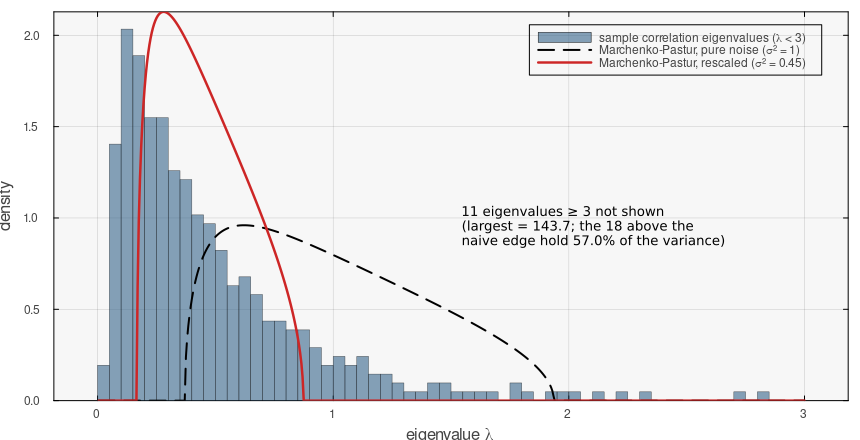

In [5]:
# Rescale the reference using the mean of the remaining eigenvalues -
K_naive = count(λ .> λ_plus); # eigenvalues above the original noise-reference edge
structured_share = sum(λ[1:K_naive])/sum(λ); # fraction of standardized variance
s²_bulk = (M - sum(λ[1:K_naive]))/(M - K_naive); # mean of the remaining eigenvalues
rescaled_lower = s²_bulk*λ_minus; # lower rescaled edge
rescaled_upper = s²_bulk*λ_plus; # upper rescaled edge
K_below_rescaled = count(λ .< rescaled_lower);
K_above_rescaled = count(λ .> rescaled_upper);
K_inside_rescaled = M - K_below_rescaled - K_above_rescaled;
println(
    "Above the pure-noise edge λ₊ = $(round(λ_plus, digits=3)): $(K_naive) eigenvalues, ",
    "holding $(round(100*structured_share, digits=1))% of the total variance",
)
println("Residual-bulk mean σ²_bulk = $(round(s²_bulk, digits=3))")
println(
    "Relative to the rescaled bulk ",
    "[$(round(rescaled_lower, digits=3)), $(round(rescaled_upper, digits=3))]: ",
    "$(K_below_rescaled) eigenvalues below, $(K_inside_rescaled) inside, ",
    "and $(K_above_rescaled) above",
)

# Compare the displayed eigenvalues with both reference densities -
let
    λ_bulk = λ[λ .< 3.0]; # restrict the display; size alone does not identify factors
    p = histogram(λ_bulk;
        bins = 0:0.05:3.0, normalize = :pdf, color = :steelblue4, alpha = 0.6, lw = 0.5,
        label = "sample correlation eigenvalues (λ < 3)",
        xlabel = "eigenvalue λ", ylabel = "density", size = (860, 440))
    xs = range(0.005, 3.0, length = 600); # eigenvalues at which to evaluate the density
    plot!(p, xs, mp.(xs, 1.0, q);
        color = :black, lw = 2, linestyle = :dash,
        label = "Marchenko-Pastur, pure noise (σ² = 1)")
    plot!(p, xs, mp.(xs, s²_bulk, q);
        color = :firebrick3, lw = 2.5,
        label = "Marchenko-Pastur, rescaled (σ² = $(round(s²_bulk, digits=2)))")
    annotation = string(
        "$(count(λ .>= 3.0)) eigenvalues ≥ 3 not shown\n",
        "(largest = $(round(λ[1], digits=1)); the $(K_naive) above the\n",
        "naive edge hold $(round(100*structured_share, digits=0))% of the variance)",
    );
    annotate!(p, 1.55, 0.45*maximum(mp.(xs, s²_bulk, q)), text(annotation, 9, :left))
    p
end


The rescaled reference shifts toward the main cluster, but the empirical spectrum extends beyond both boundaries. Heavy tails, changing volatility, and further dependence may contribute to this mismatch. The comparison identifies features to investigate; it does not establish that the remaining directions are noise.

The numerical results depend on the selected data window. Next, we will use a known covariance to measure how sampling affects its estimate.


___

## Task 2: Measure how sample size affects estimation error

In this task, we will simulate data from a known covariance and measure how accurately we can recover it. We use our empirical covariance as the fixed reference $\mathbf{\Sigma}=\hat{\mathbf{\Sigma}}_g$ for this experiment.

For each sample length $N'$, we draw independent multivariate normal growth rates with covariance $\mathbf{\Sigma}$ and re-estimate the covariance as $\hat{\mathbf{\Sigma}}'$. We use zero mean because centering removes any constant mean. The relative Frobenius error measures the discrepancy across all matrix entries:
$$
\varepsilon_F=\frac{\lVert\hat{\mathbf{\Sigma}}'-\mathbf{\Sigma}\rVert_F}{\lVert\mathbf{\Sigma}\rVert_F}.
$$
The Frobenius norm is the square root of the sum of squared entries, so this relative error is dimensionless. We also compare the smallest estimated eigenvalue with the reference value to examine combinations with low estimated variance.

Let's repeat each sample length twenty times and store the mean error, its standard deviation across replicates, and the mean smallest eigenvalue in `error_table::DataFrame`:

In [6]:
# Measure sampling error against a fixed covariance -
error_table = let
    Σ = Symmetric(Σ̂_g); # reference growth-rate covariance, 1/yr²
    d = MvNormal(zeros(M), Σ); # independent zero-mean Gaussian growth observations
    rng = MersenneTwister(5660); # reproducible random-number stream
    λ_true_min = minimum(eigvals(Σ)); # smallest reference eigenvalue, 1/yr²
    R = 20; # simulated datasets per sample length
    df = DataFrame(
        N_prime = Int[], rel_frobenius_error = Float64[], error_sd = Float64[],
        min_eig_estimate = Float64[], min_eig_true = Float64[],
    );
    for N′ ∈ (250, 500, 1000, 2000, N)
        errs = zeros(R); # relative covariance error for each simulation
        mins = zeros(R); # smallest estimated eigenvalue for each simulation, 1/yr²
        for r ∈ 1:R
            X = rand(rng, d, N′)'; # N′ × M simulated growth rates, 1/yr
            Σ′ = cov(X, dims=1); # estimated covariance, 1/yr²
            errs[r] = norm(Σ′ - Σ)/norm(Σ);
            mins[r] = minimum(eigvals(Symmetric(Σ′)));
        end
        push!(df, (N′, mean(errs), std(errs), mean(mins), λ_true_min))
    end
    df
end
pretty_table(error_table; formatters = [fmt__printf("%.4f", [2,3,4,5])])


┌─────────┬─────────────────────┬──────────┬──────────────────┬──────────────┐
│ N_prime │ rel_frobenius_error │ error_sd │ min_eig_estimate │ min_eig_true │
│   Int64 │             Float64 │  Float64 │          Float64 │      Float64 │
├─────────┼─────────────────────┼──────────┼──────────────────┼──────────────┤
│     250 │              0.2077 │   0.0337 │          -0.0000 │       0.0506 │
│     500 │              0.1379 │   0.0145 │           0.0074 │       0.0506 │
│    1000 │              0.0976 │   0.0095 │           0.0292 │       0.0506 │
│    2000 │              0.0702 │   0.0050 │           0.0394 │       0.0506 │
│    2766 │              0.0568 │   0.0045 │           0.0426 │       0.0506 │
└─────────┴─────────────────────┴──────────┴──────────────────┴──────────────┘


With $N'=250$ observations and $M=424$ firms, the centered sample covariance has rank at most $249$, so at least $175$ eigenvalues must be zero. The displayed negative zero is numerical roundoff. Even at the full sample length, the mean smallest eigenvalue remains below the reference value. These numerical results depend on the reference covariance and sample lengths.

Let's plot the relative error on logarithmic axes. The error bars show the standard deviation across replicates; the $1/\sqrt{N'}$ reference is anchored at the first point:

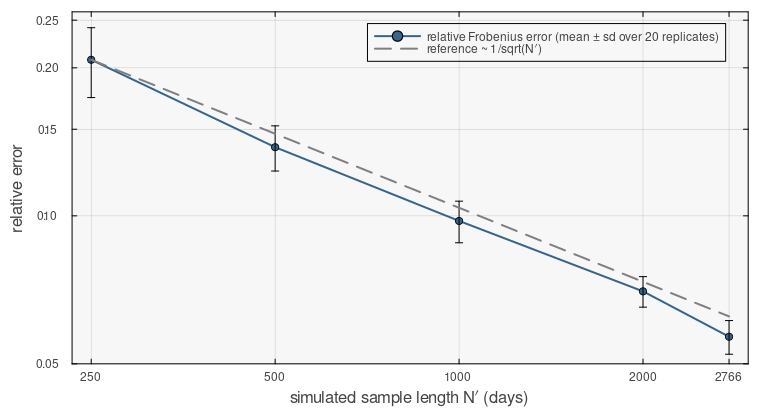

In [7]:
let
    plot(error_table.N_prime, error_table.rel_frobenius_error;
        xscale = :log10, yscale = :log10, marker = :circle, color = :steelblue4,
        yerror = error_table.error_sd,
        xticks = (error_table.N_prime, string.(error_table.N_prime)),
        yticks = ([0.05, 0.10, 0.15, 0.20, 0.25], ["0.05", "0.10", "0.15", "0.20", "0.25"]),
        ylims = (0.05, 0.26),
        label = "relative Frobenius error (mean ± sd over 20 replicates)",
        xlabel = "simulated sample length N′ (days)", ylabel = "relative error",
        size = (760, 420), legend = :topright,
        left_margin = 4 * Plots.mm, bottom_margin = 5 * Plots.mm)
    ref = error_table.rel_frobenius_error[1] .* sqrt.(error_table.N_prime[1] ./ error_table.N_prime)
    plot!(error_table.N_prime, ref; color = :gray50, linestyle = :dash,
        label = "reference ~ 1/sqrt(N′)")
end


The overall error decreases approximately as $1/\sqrt{N'}$ in this experiment with a fixed number of firms and independent Gaussian observations. Yet the smallest eigenvalue remains underestimated on average. A modest overall error can therefore coexist with unreliable low-variance combinations. Next, we will examine whether shrinkage improves the resulting portfolio calculation.


___

## Task 3: Shrink the covariance and compare portfolio risk

In this task, we will examine whether shrinking the covariance estimate improves a minimum-variance portfolio calculation on later observations. We use the first $8\times252$ daily growth observations for training and the remainder for evaluation.

### Shrinkage targets

Let $\mathbf{S}$ be the training growth-rate covariance, stored in `S_train`. __Shrinkage__ averages this estimate with a structured target $\mathbf{F}$:
$$
\hat{\mathbf{\Sigma}}_{g,\delta}=(1-\delta)\mathbf{S}+\delta\mathbf{F},
\qquad 0\leq\delta\leq1.
$$
The weight $\delta$ determines how much of the estimate comes from the target. For example, $\delta=0.2$ combines 80% of the sample covariance with 20% of the target. At $\delta=0$, we retain the sample covariance; at $\delta=1$, we use the target alone. We construct each target from training data:

| Target | Assumptions |
| :--- | :--- |
| Scaled identity | Every variance equals $\operatorname{tr}(\mathbf{S})/M$; correlations are zero. |
| Diagonal | Retain each firm's sample variance; correlations are zero. |
| Constant correlation | Retain each sample variance; all pairwise correlations equal the mean off-diagonal training correlation. |

For our dataset, these targets raise the smallest eigenvalues when $\delta>0$. This improves conditioning, but its effect on later risk must be checked. The constant-correlation approach is discussed by [Ledoit and Wolf](https://doi.org/10.3905/jpm.2004.110).

### Portfolio comparison

For each estimate, we minimize $\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_{g,\delta}\mathbf{w}$ subject to $\mathbf{1}^{\top}\mathbf{w}=1$, allowing negative weights (short positions). Here, $\mathbf{1}$ is the length-$M$ vector of ones. For a positive-definite covariance, the weights are given by:
$$
\mathbf{w}_{\min}=
\frac{\hat{\mathbf{\Sigma}}_{g,\delta}^{-1}\mathbf{1}}
{\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_{g,\delta}^{-1}\mathbf{1}}.
$$
We evaluate the lecture's __linear growth-rate proxy__ $g_p=\mathbf{w}^{\top}\mathbf{g}$, an approximation to portfolio log growth. Its sample standard deviation on the later window is computed from `G_test*w` and has units of inverse years. Equal weights $w_i=1/M$ provide a baseline.

Let's construct the training and test matrices and the three targets:

In [8]:
# Split the daily growth observations in time order -
N_train = 8*252; # 2,016 daily growth observations for training
G_train = G[1:N_train, :]; # training growth rates, 1/yr
G_test = G[(N_train+1):end, :]; # later growth rates, 1/yr
S_train = cov(G_train, dims=1); # training covariance, 1/yr²

# Construct all three targets from training data -
targets, mean_training_correlation = let
    σ = sqrt.(diag(S_train)); # training standard deviations, 1/yr
    R = S_train ./ (σ*σ'); # training correlation matrix
    ρ̄ = (sum(R) - M)/(M*(M - 1)); # mean off-diagonal training correlation
    F_cc = ρ̄ .* (σ*σ'); # common-correlation covariance entries, 1/yr²
    F_cc[diagind(F_cc)] .= σ.^2; # retain each sample variance on the diagonal
    target_dictionary = Dict(
        "scaled identity" => Matrix((tr(S_train)/M)*I(M)),
        "diagonal" => Matrix(Diagonal(diag(S_train))),
        "constant correlation" => F_cc,
    );
    (target_dictionary, ρ̄)
end;
println(
    "Training window: $(N_train) days; test window: $(size(G_test,1)) days; ",
    "average off-diagonal correlation on training: ",
    "$(round(mean_training_correlation, digits=3))",
)


Training window: 2016 days; test window: 750 days; average off-diagonal correlation on training: 0.336


Let's compare each target using several values of $\delta$, the weight placed on the target. We record the standard deviation of the linear growth-rate proxy on both windows and the __gross weight__ $\sum_i|w_i|$, stored in `sum_abs_weights`. Because the weights sum to one, a gross weight above one indicates short positions offset by larger long positions.

[The minvar(...) function](src/CovarianceEstimation.jl) computes the weights, and [the realized_std(...) function](src/CovarianceEstimation.jl) measures the proxy's standard deviation on each window. Let's store these comparisons in `shrinkage_df::DataFrame`:

In [9]:
# Compare each target and weight on the target -
shrinkage_df = let
    δ_grid = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]; # target weights
    df = DataFrame(
        target = String[], δ = Float64[], train_std = Float64[],
        test_std = Float64[], sum_abs_weights = Float64[],
    );
    for name ∈ ("scaled identity", "diagonal", "constant correlation"), δ ∈ δ_grid
        w = minvar((1 - δ)*S_train + δ*targets[name]); # fully invested; shorts allowed
        push!(df, (name, δ, realized_std(w, G_train), realized_std(w, G_test), sum(abs.(w))))
    end
    w_eq = ones(M)/M; # equal-weight baseline
    push!(df, ("equal weights 1/M", NaN, realized_std(w_eq, G_train), realized_std(w_eq, G_test), 1.0))
    df
end;


Let's now report the smallest test-window standard deviation for each target, together with its training value and gross weight. We select these values of $\delta$ using the test window, so the comparison is made with hindsight:

In [10]:
# Report the best result on this test window, chosen with hindsight -
let
    println("Best test-window standard deviation by target (δ chosen with hindsight):")
    for name ∈ ("scaled identity", "diagonal", "constant correlation")
        sdf = filter(r -> r.target == name, shrinkage_df);
        k = argmin(sdf.test_std); # index of the smallest test-window standard deviation
        println(
            "  $(rpad(name, 22)) δ = $(sdf.δ[k])  ",
            "train std = $(round(sdf.train_std[k], digits=3))  ",
            "test std = $(round(sdf.test_std[k], digits=3))  ",
            "sum|w| = $(round(sdf.sum_abs_weights[k], digits=2))",
        )
    end
    println(
        "No shrinkage (δ = 0): test std = $(round(shrinkage_df[1,:test_std], digits=3)), ",
        "sum|w| = $(round(shrinkage_df[1,:sum_abs_weights], digits=2)); ",
        "equal weights: test std = $(round(shrinkage_df[end,:test_std], digits=3))",
    )
end


Best test-window standard deviation by target (δ chosen with hindsight):


  scaled identity        δ = 0.0  train std = 0.777  test std = 1.285  sum|w| = 6.41


  diagonal               δ = 0.1  train std = 0.837  test std = 1.229  sum|w| = 4.53
  constant correlation   δ = 0.2  train std = 0.87  test std = 1.186  sum|w| = 4.64
No shrinkage (δ = 0): test std = 1.285, sum|w| = 6.41; equal weights: test std = 2.378


Let's plot the proxy's standard deviation against $\delta$, using solid lines for the test window and dashed lines for training. We show $\delta\leq0.5$ to examine moderate shrinkage; the equal-weight baseline and the $\delta=1$ results lie above this plot's vertical range.

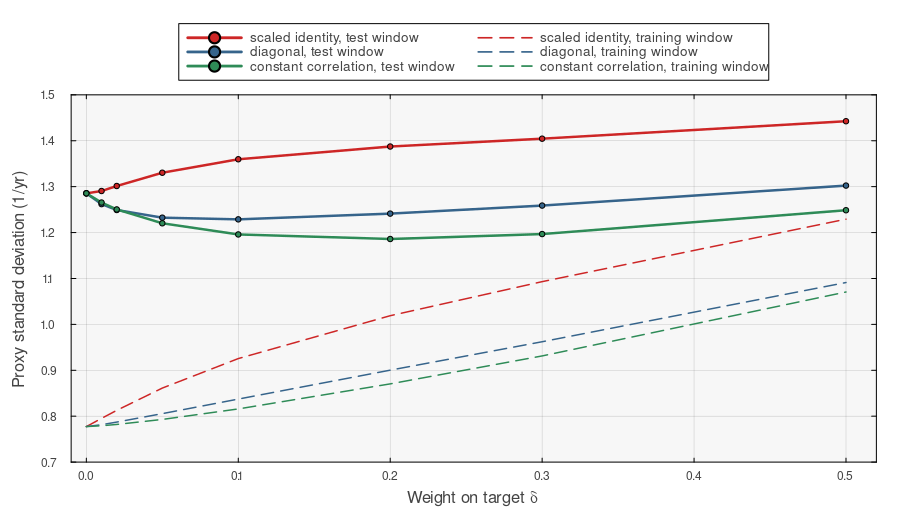

In [11]:
let
    p = plot(
        xlabel = "Weight on target δ",
        ylabel = "Proxy standard deviation (1/yr)",
        size = (900, 520),
        legend = :outertop, legend_columns = 2, legendfontsize = 9,
        xlims = (-0.01, 0.52), ylims = (0.7, 1.5),
        xticks = ([0.0, 0.1, 0.2, 0.3, 0.4, 0.5], ["0.0", "0.1", "0.2", "0.3", "0.4", "0.5"]),
        yticks = ([0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5],
            ["0.7", "0.8", "0.9", "1.0", "1.1", "1.2", "1.3", "1.4", "1.5"]),
        left_margin = 5 * Plots.mm, bottom_margin = 5 * Plots.mm,
        right_margin = 4 * Plots.mm, top_margin = 4 * Plots.mm,
    )
    colors = Dict(
        "scaled identity" => :firebrick3,
        "diagonal" => :steelblue4,
        "constant correlation" => :seagreen4,
    )
    for name ∈ ("scaled identity", "diagonal", "constant correlation")
        sdf = filter(r -> r.target == name && r.δ <= 0.5, shrinkage_df)
        plot!(p, sdf.δ, sdf.test_std;
            color = colors[name], lw = 2.5, marker = :circle, ms = 3,
            label = "$(name), test window")
        plot!(p, sdf.δ, sdf.train_std;
            color = colors[name], lw = 1.5, linestyle = :dash,
            label = "$(name), training window")
    end
    p
end


The raw estimate ($\delta=0$) gives the lowest training variance by construction: its weights minimize that same sample covariance. The later window checks how those weights perform on different observations.

In this split, moderate shrinkage toward the diagonal or constant-correlation target lowers test-window variability and reduces gross weight. Shrinking toward the scaled identity raises test-window variability at every positive value of $\delta$ examined. At $\delta=1$, the targets give test standard deviations around the equal-weight baseline; imposing the target completely loses the benefit of moderate shrinkage here.

These results depend on the data window and target. The reported best $\delta$ uses the test window, so it is selected with hindsight. Evaluating a selection rule would require choosing $\delta$ within the training data and reserving a later window for testing.

___


## Summary

In this example, we examined how sampling error in a covariance estimate affects a minimum-variance portfolio calculation.

> __Key Takeaways:__
>
> * **Spectrum as a diagnostic:** We compared the sample correlation eigenvalues with the Marchenko-Pastur reference for independent observations. Large eigenvalues indicated shared variation beyond that reference, while eigenvalue size alone could not separate signal from noise.
>
> * **Sampling error and small eigenvalues:** We simulated independent Gaussian growth rates from a fixed covariance and found that the overall estimation error decreased approximately as $1/\sqrt{N'}$. The smallest eigenvalue remained underestimated on average, showing why a modest overall error can still affect low-variance portfolio calculations.
>
> * **Shrinkage and portfolio comparisons:** We combined the sample covariance with three structured targets and compared the resulting minimum-variance portfolios. In this data split, moderate shrinkage toward the diagonal or constant-correlation target reduced the variability of the linear growth-rate proxy on the later window; the scaled-identity target did not. The best weights on the targets were selected with hindsight.

The covariance estimate is an important input to the portfolio optimization problem; we obtain the weights by solving that problem with the chosen objective and constraints.

___


## Disclaimer and Risks

This notebook is for instruction only. Covariance estimates and portfolio weights depend on the sample window and the estimator; the split-sample comparison here is one split, not a backtest. This material is not investment or trading advice.
